## Startup


80/20 rule:
80% calibration (2000-2020)
20% validation (2020-2025)

In [1]:
# General python
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

# Niceties
from rich import print

from ipywidgets import IntProgress
from IPython.display import display

In [2]:
# General eWaterCycle
import ewatercycle
import ewatercycle.models
import ewatercycle.forcing

### Defining variables & pathways

In [3]:
# Choosing time period & basin si

experiment_start_date = "2000-01-01T00:00:00Z"
experiment_end_date = "2005-12-31T00:00:00Z"

calibration_start = "1999-01-01T00:00:00Z"
calibration_end = "2019-12-31T00:00:00Z"

# validation_start = ""
# validation_end = ""

In [4]:
# # Create pathways for ERA 5 forcings

# forcing_path_ERA5 = Path.home() / "BEP-maxime" / "Workyard" / "forcings" / "ERA5-1999-2019"

# discharge_file = Path.home() / "BEP-maxime" / "Workyard" / "07DA001_discharge_daily_withoutmissing.csv"

# shape_file = Path.home() / "BEP-maxime" / "Workyard" / "Shapefiles" / "07DA001_basin.shp"
# basin_size = 132572

# calibration_temp = Path.home() / "BEP-maxime" / "Workyard" / "calibration_temp"
# calibration_temp.mkdir(parents=True, exist_ok=True)

In [5]:
# Create pathways for ERA 5 forcings

forcing_path_ERA5 = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" / "Workyard" / "forcings" / "ERA5" / "ERA5-1999-2019"

discharge_file = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" / "Workyard" / "07DA001_discharge_daily_withoutmissing.csv"

shape_file = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" / "Workyard" / "Shapefiles" / "07DA001_basin.shp"
basin_size = 132572

hbv_config = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" /  "Workyard" / "hbv_config"
hbv_config.mkdir(parents=True, exist_ok=True)

### Load & prepare discharge data 

In [6]:
# Load CSV discharge 07DA001

q_obs = pd.read_csv(discharge_file, skiprows=1)
q_obs = q_obs[["Date", "Value"]].copy()
q_obs["Date"] = pd.to_datetime(q_obs["Date"])
q_obs = q_obs.rename(columns={"Value": "discharge_m3s"})

In [7]:
# Filter q_obs to start & end date

# start_date = pd.to_datetime(experiment_start_date.replace("Z", ""))
# end_date = pd.to_datetime(experiment_end_date.replace("Z", ""))

# q_obs = q_obs[(q_obs["Date"] >= start_date) & (q_obs["Date"] <= end_date)]
# observed_output = pd.Series(data=q_obs["discharge_m3s"].to_numpy(), name="Observed discharge", index=q_obs["Date"])

### Generate or Load ERA5 data

In [8]:
# Generate ERA5 data
# ERA5_forcing = ewatercycle.forcing.sources['LumpedMakkinkForcing'].generate(
#     dataset="ERA5",
#     start_time=experiment_start_date,
#     end_time=experiment_end_date,
#     shape=shape_file,
# )

# Load ERA5 data
ERA5_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=forcing_path_ERA5)

print(ERA5_forcing)

LumpedMakkinkForcing(
    start_time='1999-01-01T00:00:00Z',
    end_time='2019-12-31T00:00:00Z',
    directory=PosixPath('/home/maxime/BEP-maxime/Workyard/forcings/ERA5-1999-2019'),
    shape=PosixPath('/home/maxime/BEP-maxime/Workyard/Shapefiles/07DA001_basin.shp'),
    filenames={
        'evspsblpot': 'combined_ERA5_1999_2019_evspsblpot.nc',
        'pr': 'combined_ERA5_1999_2019_pr.nc',
        'rsds': 'combined_ERA5_1999_2019_rsds.nc',
        'tas': 'combined_ERA5_1999_2019_tas.nc'
    }
)

## Calibration Methods

### Method 1: RMSE

In [9]:
def RMSE(sim, obs):
    sim = sim.to_numpy()
    obs = obs.to_numpy()

    return np.sqrt(np.mean((obs - sim)) ** 2)

### Method 2: NSE

In [10]:
def NSE(sim, obs):
    sim = sim.to_numpy()
    obs = obs.to_numpy()

    return 1 - np.sum((obs - sim) ** 2) / np.sum((obs - np.mean(obs)) ** 2)

### Method 3: Log_NSE

In [11]:
def log_NSE(sim, obs):
    # Convert for easy calculations
    sim = sim.to_numpy()
    obs = obs.to_numpy()

    # Avoid log(0)
    eps = 0.00000000001

    log_sim = np.log(sim + eps)
    log_obs = np.log(obs + eps)

    return 1 - np.sum((log_obs - log_sim) ** 2) / np.sum((log_obs - np.mean(log_obs)) ** 2)

### Define Parameters & Storages and Times

In [12]:
# Define initial storages
#               Si,  Su, Sf, Ss, Sp
s_0 = np.array([0,  100,  0,  5,  0])

# Define parameters (range)
parameter_ranges = {
    "Imax":  (5.5, 8),            # Maximum interception storage
    "Ce":    (0.35, 0.6),       # Evaporation correction factor
    "Sumax": (150, 220),         # Maximum soil moisture storage
    "Beta":  (1.6, 2),          # Soil runoff parameter
    "Pmax":  (0.1, 0.6),            # Maximum percolation rate
    "Tlag":  (5.2, 7),           # Time lag
    "Kf":    (0.01, 0.1),       # Fast reservoir recession coefficient
    "Ks":    (0.001, 0.1),     # Slow reservoir recession coefficient
    "FM":    (0.3, 1.4),          # Snowmelt factor
}

# Convert to arrays
parameter_names = list(parameter_ranges.keys())

p_min = np.array([parameter_ranges[name][0] for name in parameter_names])
p_max = np.array([parameter_ranges[name][1] for name in parameter_names])

### Create samples

In [13]:
### Create samples
N = 600
par_samples = np.random.rand(N, len(parameter_ranges))                  # Generates random values between 0-1
parameter_sets = p_min + par_samples * (p_max - p_min)                  # Fits value to parameter range

print(parameter_sets[:][0])

[7.85285914e+00 3.89990216e-01 1.76127959e+02 1.92058774e+00
 5.56024109e-01 6.99810960e+00 3.01314564e-02 6.63774925e-02
 9.62585104e-01]

### Define time period

In [14]:
# Define time period
calibration_start_date = pd.to_datetime(calibration_start.replace("Z", ""))
calibration_end_date = pd.to_datetime(calibration_end.replace("Z", ""))

# Skip 1 year for calibration
evaluation_start = pd.to_datetime(f"{calibration_start_date.year + 1}-01-01")

# Align q_obs
q_obs = q_obs[(q_obs["Date"] >= calibration_start_date) & (q_obs["Date"] <= calibration_end_date)]
observed_output = pd.Series(data=q_obs["discharge_m3s"].to_numpy(), name="Observed discharge", index=q_obs["Date"])

## Calibration start function

In [15]:
# Create function to run the model

def run_hbv(parameters, initial_storages, forcing):

    # Create model object
    model = ewatercycle.models.HBV(forcing=forcing)

    # Create config file
    config_file, _ = model.setup(
        parameters=parameters,
        initial_storages=initial_storages,
        cfg_dir=hbv_config)

    # Initialising model
    model.initialize(config_file)

    # Define & update outputs 
    Q_m = []
    time = []

    while model.time < model.end_time:
        model.update()
        Q_m.append(model.get_value("Q")[0])
        time.append(pd.Timestamp(model.time_as_datetime))

    model.finalize()

    # Convert mm/day to m3/s
    model_output_mmday = pd.Series(
        data=Q_m, 
        index=time, 
        name="Modelled discharge")
    
    model_output_m3s = model_output_mmday * basin_size * 1000 / 86400

    return model_output_m3s

### Run HBV loop

In [16]:
results = []

# Progress bar for visualization
f = IntProgress(min=0, max=N)
display(f)

for i in range(N):
    print(f"Running parameter set {i+1}/{N}")

    simulated = run_hbv(
        parameters=parameter_sets[i], 
        initial_storages=s_0, 
        forcing=ERA5_forcing)

    # Filter data by day only, not by day & time to prevent alignment issues
    simulated_daily = simulated
    observed_daily = observed_output

    simulated_daily.index = pd.to_datetime(simulated_daily.index).tz_localize(None).normalize()
    observed_daily.index = pd.to_datetime(observed_daily.index).tz_localize(None).normalize()
    
    # Align simulated and observed data
    combined_data = pd.DataFrame(
        {"Modelled discharge": simulated_daily, 
        "Observed discharge": observed_daily}
    ).dropna()

    # Skip first year as warm-up
    combined_data = combined_data[
        (combined_data.index >= evaluation_start) &
        (combined_data.index <= calibration_end_date)]

    # Exclude ice-affected winter period
    combined_data = combined_data[
        ~combined_data.index.month.isin([11, 12, 1, 2, 3, 4])]

    # Append results and drop nan
    if combined_data.empty:
        print(f"No overlapping data for parameter set {i+1}")
        nse = np.nan
        log_nse = np.nan
    else:
        nse = NSE(
            combined_data["Modelled discharge"], 
            combined_data["Observed discharge"])
        
        log_nse = log_NSE(
            combined_data["Modelled discharge"], 
            combined_data["Observed discharge"])
        
    results.append({
        "run": i,
        "NSE": nse,
        "log_NSE": log_nse,
        "parameters": parameter_sets[i]})

IntProgress(value=0, max=600)

Running parameter set 1/600

Running parameter set 2/600

Running parameter set 3/600

Running parameter set 4/600

...

Running parameter set 596/600

Running parameter set 597/600

Running parameter set 598/600

Running parameter set 599/600

Running parameter set 600/600

### Display best results

In [17]:
results = pd.DataFrame(results)

print(results[["run", "NSE", "log_NSE"]])

# # Best NSE
# best_run_nse = results["NSE"].idxmax()
# best_result_nse = results.loc[best_run_nse]

# best_parameters_nse = best_result_nse["parameters"]
# best_nse = best_result_nse["NSE"]

# print(f'Best run: {best_run_nse} with NSE: {best_nse}, with parameters:')
# print(list(zip(parameter_names, best_parameters_nse)))

# Best log_NSE
best_run_log_nse = results["log_NSE"].idxmax()
best_result_log_nse = results.loc[best_run_log_nse]

best_parameters_log_nse = best_result_log_nse["parameters"]
best_log_nse = best_result_log_nse["log_NSE"]

print(f'Best run: {best_run_log_nse} with log_NSE: {best_log_nse}, with parameters:')
print(list(zip(parameter_names, best_parameters_log_nse)))

run       NSE   log_NSE
0      0  0.288376  0.337195
1      1  0.279102  0.480497
2      2  0.384565  0.462463
3      3 -0.085379  0.265060
4      4  0.118825  0.395402
..   ...       ...       ...
595  595  0.378628  0.445890
596  596  0.190509  0.402412
597  597  0.034397 -0.105571
598  598  0.174568  0.090100
599  599  0.379411  0.461890

[600 rows x 3 columns]

Best run: 232 with NSE: 0.5042075946097913, with parameters:

[
    ('Imax', 6.488362330365561),
    ('Ce', 0.4845571293512798),
    ('Sumax', 218.83336737778694),
    ('Beta', 1.7699130278847444),
    ('Pmax', 0.1358146729030282),
    ('Tlag', 5.44235281882723),
    ('Kf', 0.04585512368848791),
    ('Ks', 0.008840391568068273),
    ('FM', 0.8983450417631202)
]

Best run: 451 with log_NSE: 0.5985790718618934, with parameters:

[
    ('Imax', 6.9919295474161505),
    ('Ce', 0.44128061023639964),
    ('Sumax', 183.49045936834898),
    ('Beta', 1.62907119850059),
    ('Pmax', 0.5726586861631707),
    ('Tlag', 5.2154764587256395),
    ('Kf', 0.06546844116401723),
    ('Ks', 0.0025930490563726475),
    ('FM', 1.1427426360454793)
]

In [18]:
# Get ensemble 

best_5_runs = results["log_NSE"].nlargest(5).index

best_5_parameters = []
best_5_LNSE = []

for i in range(len(best_5_runs)):

    run = best_5_runs[i]
    result = results.loc[run]

    parameters = result["parameters"]
    lnse = result["log_NSE"]

    best_5_parameters.append(parameters)
    best_5_LNSE.append(log_nse)

    print(f"Rank {i+1}: run {run} with LNSE: {lnse}")
    print(list(zip(parameter_names, parameters)))
    print()

Rank 1: run 451 with LNSE: 0.5985790718618934

[
    ('Imax', 6.9919295474161505),
    ('Ce', 0.44128061023639964),
    ('Sumax', 183.49045936834898),
    ('Beta', 1.62907119850059),
    ('Pmax', 0.5726586861631707),
    ('Tlag', 5.2154764587256395),
    ('Kf', 0.06546844116401723),
    ('Ks', 0.0025930490563726475),
    ('FM', 1.1427426360454793)
]

Rank 2: run 193 with LNSE: 0.5871245105302814

[
    ('Imax', 5.882658193683639),
    ('Ce', 0.47241275652770587),
    ('Sumax', 194.30386240959916),
    ('Beta', 1.781621276884348),
    ('Pmax', 0.4608178778064105),
    ('Tlag', 5.215364575839981),
    ('Kf', 0.06419932503784231),
    ('Ks', 0.015979806886031615),
    ('FM', 1.0919722363345776)
]

Rank 3: run 71 with LNSE: 0.5802931655594039

[
    ('Imax', 6.279358279165555),
    ('Ce', 0.45738099679628363),
    ('Sumax', 218.06826364855027),
    ('Beta', 1.8389403651683596),
    ('Pmax', 0.49366891001367486),
    ('Tlag', 6.037707687593043),
    ('Kf', 0.07007118899924838),
    ('Ks', 0.024409700594446738),
    ('FM', 1.2556224532809368)
]

Rank 4: run 152 with LNSE: 0.5697643546613578

[
    ('Imax', 7.301551796430246),
    ('Ce', 0.49391712556044987),
    ('Sumax', 211.00486173599964),
    ('Beta', 1.9612109256650778),
    ('Pmax', 0.46785716423961),
    ('Tlag', 6.467897643950326),
    ('Kf', 0.055226399867357515),
    ('Ks', 0.03429434734237983),
    ('FM', 1.191697747701756)
]

Rank 5: run 232 with LNSE: 0.5666729995545778

[
    ('Imax', 6.488362330365561),
    ('Ce', 0.4845571293512798),
    ('Sumax', 218.83336737778694),
    ('Beta', 1.7699130278847444),
    ('Pmax', 0.1358146729030282),
    ('Tlag', 5.44235281882723),
    ('Kf', 0.04585512368848791),
    ('Ks', 0.008840391568068273),
    ('FM', 0.8983450417631202)
]

### Plot Observed vs Modelled

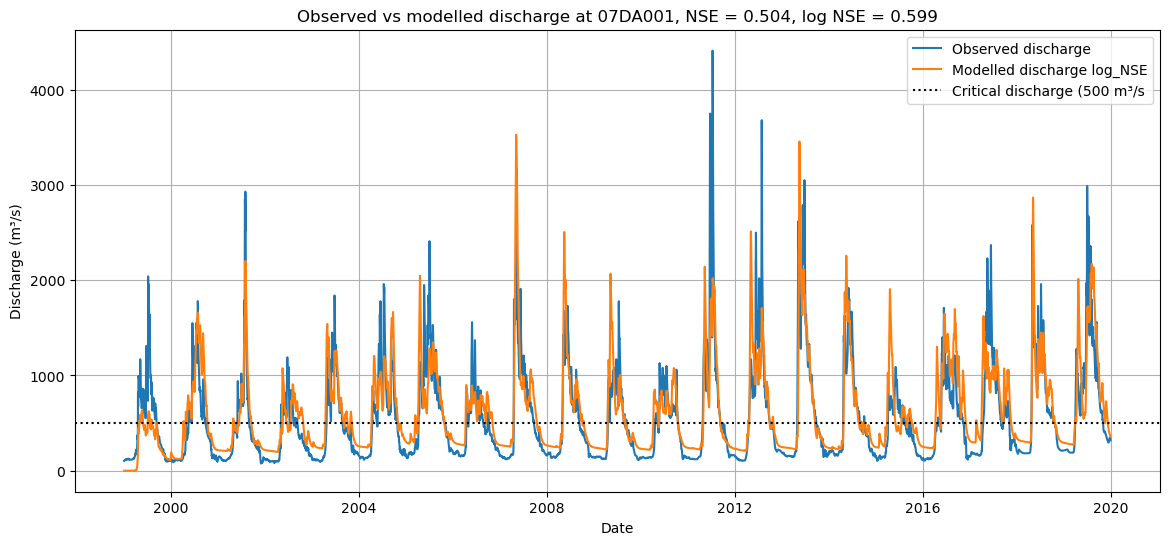

In [22]:
# Overall Plot

q_critical = 500

simulated_calibrated_nse = run_hbv(
    parameters=best_parameters_nse,
    initial_storages=s_0,
    forcing=ERA5_forcing)

simulated_calibrated_log_nse = run_hbv(
    parameters=best_parameters_log_nse,
    initial_storages=s_0,
    forcing=ERA5_forcing)

# Align dates
simulated_plot_nse = simulated_calibrated_nse
simulated_plot_log_nse = simulated_calibrated_log_nse
observed_plot = observed_output

simulated_plot_nse.index = pd.to_datetime(simulated_plot_nse.index).tz_localize(None).normalize()
simulated_plot_log_nse.index = pd.to_datetime(simulated_plot_log_nse.index).tz_localize(None).normalize()
observed_plot.index = pd.to_datetime(observed_plot.index).tz_localize(None).normalize()

# Combine modelled and observed data
plot_data = pd.DataFrame({
    "Modelled discharge NSE": simulated_plot_nse,
    "Modelled discharge log_NSE": simulated_plot_log_nse,
    "Observed discharge": observed_plot}).dropna()

# Calculate NSE & log NSE for plotted data
plot_nse = NSE(
    plot_data["Modelled discharge NSE"],
    plot_data["Observed discharge"])

plot_log_nse = log_NSE(
    plot_data["Modelled discharge log_NSE"],
    plot_data["Observed discharge"])

# Plot
plt.figure(figsize=(14, 6))
plt.plot(plot_data.index, plot_data["Observed discharge"], label="Observed discharge")
# plt.plot(plot_data.index, plot_data["Modelled discharge NSE"], label="Modelled discharge NSE")
plt.plot(plot_data.index, plot_data["Modelled discharge log_NSE"], label="Modelled discharge log_NSE")

plt.xlabel("Date")
plt.ylabel("Discharge (m³/s)")
plt.title(f"Observed vs modelled discharge at 07DA001, NSE = {best_nse:.3f}, log NSE = {best_log_nse:.3f}")
plt.axhline(y=q_critical, linestyle=":", label=f'Critical discharge ({q_critical} m³/s', color='black')
plt.legend()
plt.grid(True)
plt.show()

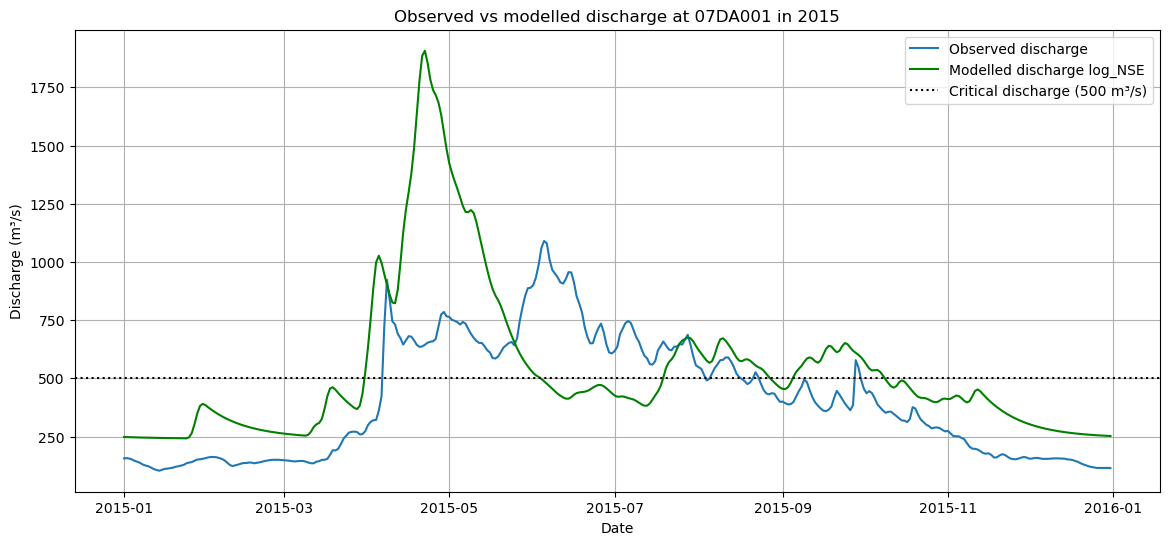

In [23]:
# Plot for 1 year

selected_year = 2015

plot_data_year = plot_data[plot_data.index.year == selected_year]

plt.figure(figsize=(14, 6))

plt.plot(plot_data_year.index,plot_data_year["Observed discharge"],label="Observed discharge")
# plt.plot(plot_data_year.index,plot_data_year["Modelled discharge NSE"],label="Modelled discharge NSE")
plt.plot(plot_data_year.index,plot_data_year["Modelled discharge log_NSE"],label="Modelled discharge log_NSE", color="green")

plt.axhline(y=q_critical,linestyle=":",color="black",label=f"Critical discharge ({q_critical} m³/s)")

plt.xlabel("Date")
plt.ylabel("Discharge (m³/s)")
plt.title(f"Observed vs modelled discharge at 07DA001 in {selected_year}")
plt.legend()
plt.grid(True)
plt.show()

In [21]:
# Calculate RMSE for best parameter sets NSE and log_NSE

rmse_nse = RMSE(
    plot_data["Modelled discharge NSE"],
    plot_data["Observed discharge"])

rmse_log_nse = RMSE(
    plot_data["Modelled discharge log_NSE"],
    plot_data["Observed discharge"])

print(f"RMSE for best NSE parameter set: {rmse_nse:.3f} m³/s")
print(f"RMSE for best log_NSE parameter set: {rmse_log_nse:.3f} m³/s")

RMSE for best NSE parameter set: 52.403 m³/s

RMSE for best log_NSE parameter set: 64.551 m³/s